# Recommender System

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
orders = pd.read_csv('clean_orders.csv')
orders.head()

,customer_id,order_id,product_code,product_name,quantity,unit_price,purchase_date,line_total,is_subproduct
0,T24540,TS010135579,362,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,1,756.0,2024-01-01,756.0,False
1,T24667,TS010135506,1212,Lancome Hypnose Kadın Parfüm Edp 75 Ml,1,2990.0,2024-01-01,2990.0,False
2,T24668,TS010135510,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False
3,ts_1704131707_8429,TS010135585,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False
4,T1186,TS010135548,3480,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,1,916.5,2024-01-01,916.5,False


In [ ]:
n_users = orders['customer_id'].nunique()
print("Unique users:", n_users)

Unique users: 34199


In [ ]:
#First lets check how many users have only one order (maybe they are guests or 1 time users)
#Either way if we only have one order it will change how we build the user-item matrix
orders_per_user = (
    orders[['customer_id','order_id']]
    .drop_duplicates()
    .groupby('customer_id')
    .size()
)

orders_per_user.describe()

,0
count,34199.000000
mean,1.562473
std,9.864421
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1279.000000


In [ ]:
one_order_users = (orders_per_user == 1).sum()
multi_order_users = (orders_per_user > 1).sum()

print("Users with 1 order:", one_order_users)
print("Users with >1 order:", multi_order_users)
print("% single-order users:", one_order_users / len(orders_per_user))

Users with 1 order: 28730
Users with >1 order: 5469
% single-order users: 0.8400830433638411


In [ ]:
#since 84% are one time users, we will build user item matrix as binary
#there were some issues with memory due to size so had to use the following library

from scipy.sparse import csr_matrix

USER_COL = "customer_id"
ITEM_COL = "product_name"

ui = orders[[USER_COL, ITEM_COL]].drop_duplicates()

# factorize ids to integer indices
user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

# build sparse user-item matrix directly
X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.uint8), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

# wrap as a pandas DataFrame *without densifying*
user_item_df = pd.DataFrame.sparse.from_spmatrix(
    X_ui,
    index=user_index,
    columns=item_index
)

user_item_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34199 entries, T24540 to ts_1771411550_1459
Columns: 11169 entries, Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml to Golden Rose Dream Eyes Eyeliner Göz Kalemi 411
dtypes: Sparse[uint8, 0](11169)
memory usage: 680.8+ KB


In [ ]:
user_item_df.head()

,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,Lancome Hypnose Kadın Parfüm Edp 75 Ml,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt 100 Ml,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,Giorgio Armani Code Femme Kadın Parfüm Edp 75 Ml,Giorgio Armani Acqua Di Gioia Kadın Parfüm Edp 100 Ml,Taft Ultra Saç Spreyi 250 Ml,Vi-Vet Yüz Sir Ağda Bandı Portakallı 24'lü,Solingen Tırnak Makası 312,Orkid Ultra Extra Hijyenik Ped Uzun Tekli Paket 7'li,...,L'Oréal Paris Elseve Dream Long Onarıcı Bakım Şampuanı 300 Ml,Avenir Lip Balm Vegan Formula Aloevera 5.2 Gr,Creme Supreme Full Kit 7-16 Küllü Soğuk Kumral,Note Velvet Blur Tint Ruj 01,Pastel CoverStick Kapatıcı 04,Çift Kaplan 210 Saten İnce Askı Bayan Atlet Siyah,Çift Kaplan 210 Saten İnce Askı Bayan Atlet Ten,Golden Rose Iconic Blush Duo No:04 Soft Pink,Golden Rose Just Touch Liquid Concealer N:05,Golden Rose Dream Eyes Eyeliner Göz Kalemi 411
T24540,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T24667,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T24668,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ts_1704131707_8429,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T1186,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Collaborative Filtering using KNN**

In [ ]:
# =========================
# Item-based kNN Collaborative Filtering (Cosine)
# - Builds sparse user-item matrix (binary)
# - Leave-one-out split
# - Fits NearestNeighbors on item vectors
# - Recommends per user
# - Evaluates HitRate@K and MRR@K
# =========================

from sklearn.neighbors import NearestNeighbors

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "product_name"

ui = orders[[USER_COL, ITEM_COL]].drop_duplicates()

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit item-based kNN on TRAIN data (items × users)
# -------------------------
X_iu_train = X_train.T.tocsr()  # items × users

K_NEIGHBORS = 200  # neighbors to consider per seed item (100–300 common)
knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=K_NEIGHBORS + 1, n_jobs=-1)
knn.fit(X_iu_train)

# -------------------------
# 3) Recommend for a user (row index)
#    Score candidate items by sum(similarity) over items the user already has
# -------------------------
def recommend_knn_user(u: int,
                       X_train: csr_matrix,
                       X_iu_train: csr_matrix,
                       knn: NearestNeighbors,
                       topn: int = 10,
                       k_neighbors: int = 200):
    user_items = X_train[u].indices
    if len(user_items) == 0:
        return pd.DataFrame(columns=["product", "score"])

    user_item_set = set(user_items.tolist())
    scores = {}

    for j in user_items:
        dists, nbrs = knn.kneighbors(X_iu_train[j], n_neighbors=k_neighbors + 1)
        dists = dists.ravel()[1:]  # drop itself
        nbrs  = nbrs.ravel()[1:]
        sims = 1.0 - dists

        for nb, s in zip(nbrs, sims):
            if nb in user_item_set:
                continue
            scores[nb] = scores.get(nb, 0.0) + float(s)

    if not scores:
        return pd.DataFrame(columns=["product", "score"])

    items = np.fromiter(scores.keys(), dtype=np.int32)
    sc    = np.fromiter(scores.values(), dtype=np.float32)

    top_idx = np.argpartition(-sc, topn)[:topn]
    top_idx = top_idx[np.argsort(-sc[top_idx])]

    return pd.DataFrame({
        "product": item_names[items[top_idx]],
        "score": sc[top_idx]
    })

def recommend_knn(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_knn_user(u, X_train, X_iu_train, knn, topn=topn, k_neighbors=K_NEIGHBORS)

# Example:
# recommend_knn(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_knn(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             X_iu_train: csr_matrix,
             knn: NearestNeighbors,
             K: int = 20,
             k_neighbors: int = 200):

    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        rec = recommend_knn_user(
            u, X_train, X_iu_train, knn, topn=K, k_neighbors=k_neighbors
        )

        n += 1
        if rec.empty:
            continue

        rec_items = rec["product"].to_numpy()
        # map recommended product names back to item indices for rank check
        # (faster: keep indices in recommend_knn_user; this is simple and readable)
        # We'll do rank based on names by comparing to item_names[t]
        target_name = item_names[t]
        where = np.where(rec_items == target_name)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_knn = eval_knn(X_train, test_item_by_user, eval_users, X_iu_train, knn, K=20, k_neighbors=K_NEIGHBORS)
print(metrics_knn)

X_ui shape (users, items): (34199, 11169) | nnz: 84707
X_train nnz: 71134 | eval_users: 13573
{'K': 20, 'users_evaluated': 13573, 'hit_rate@K': 0.11110292492448243, 'mrr@K': 0.04728682245239316}


**Collaborative Filtering: Implicit ALS Algorithm**

In [ ]:
# =========================
# Implicit ALS (Alternating Least Squares) Recommender
# - Uses your environment's convention: model.fit() expects USERS × ITEMS
# - Builds sparse user-item matrix (binary)
# - Leave-one-out split
# - Trains ALS on TRAIN only
# - Recommends per user
# - Evaluates HitRate@K and MRR@K
# =========================

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import implicit

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "product_name"

ui = orders[[USER_COL, ITEM_COL]].drop_duplicates()

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Train ALS on TRAIN matrix
#    IMPORTANT (your environment): fit() expects USERS × ITEMS
# -------------------------
alpha = 40.0
factors = 64
regularization = 0.05
iterations = 30

C_train = X_train.tocsr().astype(np.float32) * alpha  # confidence-weighted

model = implicit.als.AlternatingLeastSquares(
    factors=factors,
    regularization=regularization,
    iterations=iterations,
    random_state=42
)
model.fit(C_train)

# sanity check: these MUST match (n_users, factors) and (n_items, factors)
n_users, n_items = X_train.shape
print("Expected user_factors:", (n_users, factors), "Got:", model.user_factors.shape)
print("Expected item_factors:", (n_items, factors), "Got:", model.item_factors.shape)

# -------------------------
# 3) Recommend for a user
#    Key details to avoid the earlier ValueError:
#      - userid MUST be an int row index
#      - user_items must have 1 row for scalar userid OR pass full matrix with scalar userid (works here)
# -------------------------
def recommend_als(customer_id, N=10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])

    u = int(user_to_row[customer_id])

    ids, scores = model.recommend(
        userid=u,
        user_items=X_train[u],   # <-- 1 row only
        N=N,
        filter_already_liked_items=True
    )

    return pd.DataFrame({"product": item_names[ids], "score": scores})

# Example:
# recommend_als(user_index[0], N=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_als(model, X_train, test_item_by_user, eval_users, K=20):
    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        rec_ids, _ = model.recommend(
            userid=int(u),
            user_items=X_train[u],   # <-- 1 row only
            N=K,
            filter_already_liked_items=True
        )

        n += 1
        where = np.where(rec_ids == t)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {"K": K, "users_evaluated": n, "hit_rate@K": hits / n if n else 0.0, "mrr@K": mrr / n if n else 0.0}

metrics_als = eval_als(model, X_train, test_item_by_user, eval_users, K=20)
print(metrics_als)

X_ui shape (users, items): (34199, 11169) | nnz: 84707
X_train nnz: 71134 | eval_users: 13573


  0%|          | 0/30 [00:00<?, ?it/s]

Expected user_factors: (34199, 64) Got: (34199, 64)
Expected item_factors: (11169, 64) Got: (11169, 64)
{'K': 20, 'users_evaluated': 13573, 'hit_rate@K': 0.18883076696382525, 'mrr@K': 0.07552918982584456}


**Colaborative Filtering: Truncated SVD**

In [ ]:
# =========================
# Truncated SVD Recommender
# - No TF-IDF weighting
# - Uses Pipeline + Normalizer
# - Includes leave-one-out split, recommend(), and evaluation (HitRate@K, MRR@K)
# =========================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "product_name"

ui = orders[[USER_COL, ITEM_COL]].drop_duplicates()

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
#    (only evaluates users with >=2 interacted items)
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit TruncatedSVD + Normalizer pipeline
# -------------------------
n_factors = 300  # try 50/100/200 and compare metrics
svd = TruncatedSVD(n_components=n_factors, random_state=42)
svd_model = make_pipeline(svd, Normalizer(copy=False))

# Use float32 to reduce memory; X_train is sparse (users × items)
X_train_w = X_train.astype(np.float32)

U = svd_model.fit_transform(X_train_w)                        # users × k
Vt = svd_model.named_steps["truncatedsvd"].components_        # k × items

print("U shape:", U.shape, "| Vt shape:", Vt.shape)

# -------------------------
# 3) Recommendation functions
# -------------------------
def recommend_svd_user(u: int, X_train: csr_matrix, U: np.ndarray, Vt: np.ndarray, topn: int = 10):
    # scores for all items
    scores = U[u].dot(Vt)  # (n_items,)

    # filter already-seen items
    seen = X_train[u].indices
    scores[seen] = -np.inf

    # top-n efficiently
    top_idx = np.argpartition(-scores, topn)[:topn]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    return pd.DataFrame({
        "product": item_names[top_idx],
        "score": scores[top_idx]
    })

def recommend_svd(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_svd_user(u, X_train, U, Vt, topn=topn)

# Example:
# recommend_svd(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_svd(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             U: np.ndarray,
             Vt: np.ndarray,
             K: int = 20):
    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        scores = U[u].dot(Vt)
        scores[X_train[u].indices] = -np.inf

        top_idx = np.argpartition(-scores, K)[:K]
        top_idx = top_idx[np.argsort(-scores[top_idx])]

        n += 1
        where = np.where(top_idx == t)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_svd = eval_svd(X_train, test_item_by_user, eval_users, U, Vt, K=20)
print(metrics_svd)

X_ui shape (users, items): (34199, 11169) | nnz: 84707
X_train nnz: 71134 | eval_users: 13573
U shape: (34199, 300) | Vt shape: (300, 11169)
{'K': 20, 'users_evaluated': 13573, 'hit_rate@K': 0.13379503425919104, 'mrr@K': 0.056510236882194864}


**Model Comparisons**

In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Item-based CF (kNN)",
        "HitRate@20": metrics_knn["hit_rate@K"],
        "MRR@20": metrics_knn["mrr@K"],
        "Users Evaluated": metrics_knn["users_evaluated"]
    },
    {
        "Model": "Truncated SVD",
        "HitRate@20": metrics_svd["hit_rate@K"],
        "MRR@20": metrics_svd["mrr@K"],
        "Users Evaluated": metrics_svd["users_evaluated"]
    },
    {
        "Model": "Implicit ALS",
        "HitRate@20": metrics_als["hit_rate@K"],
        "MRR@20": metrics_als["mrr@K"],
        "Users Evaluated": metrics_als["users_evaluated"]
    }
])

comparison = comparison.sort_values("HitRate@20", ascending=False)

comparison

,Model,HitRate@20,MRR@20,Users Evaluated
2,Implicit ALS,0.188831,0.075529,13573
1,Truncated SVD,0.133795,0.056510,13573
0,Item-based CF (kNN),0.111103,0.047287,13573


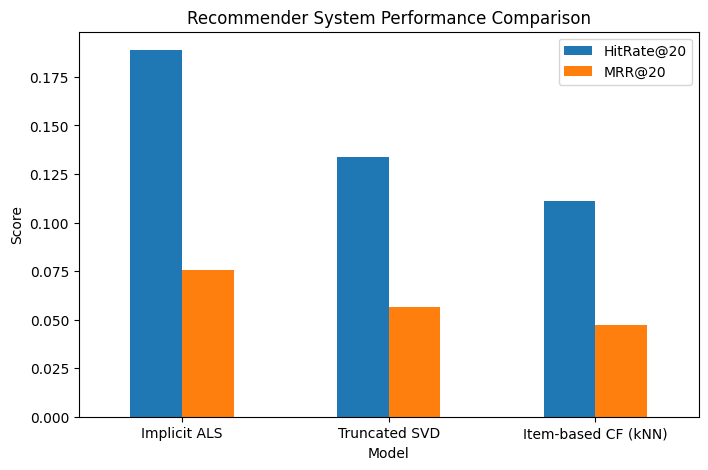

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["HitRate@20","MRR@20"]].plot.bar(figsize=(8,5))
plt.title("Recommender System Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Recommender for categories instead of products**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
orders = pd.read_csv('clean_orders.csv')
orders.head()

,customer_id,order_id,product_code,product_name,quantity,unit_price,purchase_date,line_total,is_subproduct
0,T24540,TS010135579,362,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,1,756.0,2024-01-01,756.0,False
1,T24667,TS010135506,1212,Lancome Hypnose Kadın Parfüm Edp 75 Ml,1,2990.0,2024-01-01,2990.0,False
2,T24668,TS010135510,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False
3,ts_1704131707_8429,TS010135585,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False
4,T1186,TS010135548,3480,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,1,916.5,2024-01-01,916.5,False


In [ ]:
products = pd.read_csv('clean_products.csv')
products.head()

,product_name,product_code,category_main,category_mid,category_sub,full_path,price_original,price_discounted,brand,discount_pct,price_anomaly,ever_purchased
0,Sesu Sir Ağda Bantları Normal Tüyler 12'li,24568,Kişisel Bakım,Epilasyon Ürünleri,Ağda Bantları,Kişisel Bakım > Epilasyon Ürünleri > Ağda Bant...,0.0,0.0,Sesu,0.0,False,False
1,Sesu Vücut Ağda Bandı Kalın Tüy 12'li,24569,Kişisel Bakım,Epilasyon Ürünleri,Ağda Bantları,Kişisel Bakım > Epilasyon Ürünleri > Ağda Bant...,0.0,0.0,Sesu,0.0,False,False
2,YSL La Vestiaire Universite Unisex Parfüm Edp ...,117829,Parfüm,Unisex Parfüm,EDP Parfüm,Parfüm > Unisex Parfüm >EDP Parfüm,0.0,0.0,YSL,0.0,False,False
3,Pastel Show By Eyeliner 124,1458-907,Makyaj,Göz,Eyeliner,Makyaj > Göz > Eyeliner,0.0,0.0,Pastel,0.0,False,False
4,L'Oréal Paris Infaillible 24H Matte Cover Foun...,1135-1044,Makyaj,Yüz,Fondöten,Makyaj > Yüz > Fondöten,0.0,0.0,Loreal Paris Makyaj,0.0,False,True


In [ ]:
products_unique = products[['product_name','category_sub', 'brand']].drop_duplicates()
orders2 = orders.merge(
    products_unique,
    left_on='product_name',
    right_on='product_name',
    how='left'
)
orders2.head()

,customer_id,order_id,product_code,product_name,quantity,unit_price,purchase_date,line_total,is_subproduct,category_sub,brand
0,T24540,TS010135579,362,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,1,756.0,2024-01-01,756.0,False,Göz & Dudak Bakım,Clinique
1,T24667,TS010135506,1212,Lancome Hypnose Kadın Parfüm Edp 75 Ml,1,2990.0,2024-01-01,2990.0,False,EDP Parfüm,Lancome
2,T24668,TS010135510,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False,EDT Parfüm,Carolina Herrera
3,ts_1704131707_8429,TS010135585,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False,EDT Parfüm,Carolina Herrera
4,T1186,TS010135548,3480,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,1,916.5,2024-01-01,916.5,False,Deo Stick,YSL


In [ ]:
from scipy.sparse import csr_matrix

USER_COL = "customer_id"
ITEM_COL = "category_sub"

ui = orders2[[USER_COL, ITEM_COL]].drop_duplicates()
ui = ui.dropna(subset=[ITEM_COL])
# factorize ids to integer indices
user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

# build sparse user-item matrix directly
X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.uint8), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

# wrap as a pandas DataFrame *without densifying*
user_item_df = pd.DataFrame.sparse.from_spmatrix(
    X_ui,
    index=user_index,
    columns=item_index
)

user_item_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32680 entries, T24540 to ts_1771411550_1459
Columns: 137 entries, Göz & Dudak Bakım to Erkek Çocuk Giyim
dtypes: Sparse[uint8, 0](137)
memory usage: 533.5+ KB


In [ ]:
user_item_df.head()

,Göz & Dudak Bakım,EDP Parfüm,EDT Parfüm,Deo Stick,Saç Spreyi,Ağda Bantları,Tırnak Bakım,Hijyenik Pedler,Diş Fırçaları,Deodorant,...,Slip,Atlet,Mayo,Bikini Takımı,Gecelik,T-Shirt,Tayt,Pijama,Fanila,Erkek Çocuk Giyim
T24540,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
T24667,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T24668,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ts_1704131707_8429,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T1186,0,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.neighbors import NearestNeighbors

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "category_sub"

ui = orders2[[USER_COL, ITEM_COL]].drop_duplicates()
ui = ui.dropna(subset=[ITEM_COL])

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit item-based kNN on TRAIN data (items × users)
# -------------------------
X_iu_train = X_train.T.tocsr()  # items × users

K_NEIGHBORS = 50  # neighbors to consider per seed item (100–300 common)
knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=K_NEIGHBORS + 1, n_jobs=-1)
knn.fit(X_iu_train)

# -------------------------
# 3) Recommend for a user (row index)
#    Score candidate items by sum(similarity) over items the user already has
# -------------------------
def recommend_knn_user(u: int,
                       X_train: csr_matrix,
                       X_iu_train: csr_matrix,
                       knn: NearestNeighbors,
                       topn: int = 10,
                       k_neighbors: int = 200):
    user_items = X_train[u].indices
    if len(user_items) == 0:
        return pd.DataFrame(columns=["product", "score"])

    user_item_set = set(user_items.tolist())
    scores = {}

    for j in user_items:
        dists, nbrs = knn.kneighbors(X_iu_train[j], n_neighbors=k_neighbors + 1)
        dists = dists.ravel()[1:]  # drop itself
        nbrs  = nbrs.ravel()[1:]
        sims = 1.0 - dists

        for nb, s in zip(nbrs, sims):
            if nb in user_item_set:
                continue
            scores[nb] = scores.get(nb, 0.0) + float(s)

    if not scores:
        return pd.DataFrame(columns=["product", "score"])

    items = np.fromiter(scores.keys(), dtype=np.int32)
    sc    = np.fromiter(scores.values(), dtype=np.float32)

    top_idx = np.argpartition(-sc, topn)[:topn]
    top_idx = top_idx[np.argsort(-sc[top_idx])]

    return pd.DataFrame({
        "product": item_names[items[top_idx]],
        "score": sc[top_idx]
    })

def recommend_knn(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_knn_user(u, X_train, X_iu_train, knn, topn=topn, k_neighbors=K_NEIGHBORS)

# Example:
# recommend_knn(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_knn(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             X_iu_train: csr_matrix,
             knn: NearestNeighbors,
             K: int = 20,
             k_neighbors: int = 200):

    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        rec = recommend_knn_user(
            u, X_train, X_iu_train, knn, topn=K, k_neighbors=k_neighbors
        )

        n += 1
        if rec.empty:
            continue

        rec_items = rec["product"].to_numpy()
        # map recommended product names back to item indices for rank check
        # (faster: keep indices in recommend_knn_user; this is simple and readable)
        # We'll do rank based on names by comparing to item_names[t]
        target_name = item_names[t]
        where = np.where(rec_items == target_name)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_knn = eval_knn(X_train, test_item_by_user, eval_users, X_iu_train, knn, K=10, k_neighbors=K_NEIGHBORS)
print(metrics_knn)

X_ui shape (users, items): (32680, 137) | nnz: 56980
X_train nnz: 47260 | eval_users: 9720
{'K': 10, 'users_evaluated': 9720, 'hit_rate@K': 0.42191358024691356, 'mrr@K': 0.1978112548174264}


In [ ]:
# =========================
# Implicit ALS (Alternating Least Squares) Recommender
# - Uses your environment's convention: model.fit() expects USERS × ITEMS
# - Builds sparse user-item matrix (binary)
# - Leave-one-out split
# - Trains ALS on TRAIN only
# - Recommends per user
# - Evaluates HitRate@K and MRR@K
# =========================

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import implicit

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "category_sub"

ui = orders2[[USER_COL, ITEM_COL]].drop_duplicates()
ui = ui.dropna(subset=[ITEM_COL])

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Train ALS on TRAIN matrix
#    IMPORTANT (your environment): fit() expects USERS × ITEMS
# -------------------------
alpha = 20.0
factors = 10
regularization = 0.1
iterations = 50

C_train = X_train.tocsr().astype(np.float32) * alpha  # confidence-weighted

model = implicit.als.AlternatingLeastSquares(
    factors=factors,
    regularization=regularization,
    iterations=iterations,
    random_state=42
)
model.fit(C_train)

# sanity check: these MUST match (n_users, factors) and (n_items, factors)
n_users, n_items = X_train.shape
print("Expected user_factors:", (n_users, factors), "Got:", model.user_factors.shape)
print("Expected item_factors:", (n_items, factors), "Got:", model.item_factors.shape)

# -------------------------
# 3) Recommend for a user
#    Key details to avoid the earlier ValueError:
#      - userid MUST be an int row index
#      - user_items must have 1 row for scalar userid OR pass full matrix with scalar userid (works here)
# -------------------------
def recommend_als(customer_id, N=10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])

    u = int(user_to_row[customer_id])

    ids, scores = model.recommend(
        userid=u,
        user_items=X_train[u],   # <-- 1 row only
        N=N,
        filter_already_liked_items=True
    )

    return pd.DataFrame({"product": item_names[ids], "score": scores})

# Example:
# recommend_als(user_index[0], N=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_als(model, X_train, test_item_by_user, eval_users, K=20):
    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        rec_ids, _ = model.recommend(
            userid=int(u),
            user_items=X_train[u],   # <-- 1 row only
            N=K,
            filter_already_liked_items=True
        )

        n += 1
        where = np.where(rec_ids == t)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {"K": K, "users_evaluated": n, "hit_rate@K": hits / n if n else 0.0, "mrr@K": mrr / n if n else 0.0}

metrics_als = eval_als(model, X_train, test_item_by_user, eval_users, K=10)
print(metrics_als)

X_ui shape (users, items): (32680, 137) | nnz: 56980
X_train nnz: 47260 | eval_users: 9720


  0%|          | 0/50 [00:00<?, ?it/s]

Expected user_factors: (32680, 10) Got: (32680, 10)
Expected item_factors: (137, 10) Got: (137, 10)
{'K': 10, 'users_evaluated': 9720, 'hit_rate@K': 0.3934156378600823, 'mrr@K': 0.1735691423345745}


In [ ]:
# =========================
# Truncated SVD Recommender
# - No TF-IDF weighting
# - Uses Pipeline + Normalizer
# - Includes leave-one-out split, recommend(), and evaluation (HitRate@K, MRR@K)
# =========================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------
USER_COL = "customer_id"
ITEM_COL = "category_sub"

ui = orders2[[USER_COL, ITEM_COL]].drop_duplicates()
ui = ui.dropna(subset=[ITEM_COL])

user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

X_ui = csr_matrix(
    (np.ones(len(ui), dtype=np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
#    (only evaluates users with >=2 interacted items)
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit TruncatedSVD + Normalizer pipeline
# -------------------------
n_factors = 4  # try 50/100/200 and compare metrics
svd = TruncatedSVD(n_components=n_factors, random_state=42)
svd_model = make_pipeline(svd, Normalizer(copy=False))

# Use float32 to reduce memory; X_train is sparse (users × items)
X_train_w = X_train.astype(np.float32)

U = svd_model.fit_transform(X_train_w)                        # users × k
Vt = svd_model.named_steps["truncatedsvd"].components_        # k × items

print("U shape:", U.shape, "| Vt shape:", Vt.shape)

# -------------------------
# 3) Recommendation functions
# -------------------------
def recommend_svd_user(u: int, X_train: csr_matrix, U: np.ndarray, Vt: np.ndarray, topn: int = 10):
    # scores for all items
    scores = U[u].dot(Vt)  # (n_items,)

    # filter already-seen items
    seen = X_train[u].indices
    scores[seen] = -np.inf

    # top-n efficiently
    top_idx = np.argpartition(-scores, topn)[:topn]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    return pd.DataFrame({
        "product": item_names[top_idx],
        "score": scores[top_idx]
    })

def recommend_svd(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_svd_user(u, X_train, U, Vt, topn=topn)

# Example:
# recommend_svd(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_svd(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             U: np.ndarray,
             Vt: np.ndarray,
             K: int = 20):
    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        scores = U[u].dot(Vt)
        scores[X_train[u].indices] = -np.inf

        top_idx = np.argpartition(-scores, K)[:K]
        top_idx = top_idx[np.argsort(-scores[top_idx])]

        n += 1
        where = np.where(top_idx == t)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_svd = eval_svd(X_train, test_item_by_user, eval_users, U, Vt, K=10)
print(metrics_svd)

X_ui shape (users, items): (32680, 137) | nnz: 56980
X_train nnz: 47260 | eval_users: 9720
U shape: (32680, 4) | Vt shape: (4, 137)
{'K': 10, 'users_evaluated': 9720, 'hit_rate@K': 0.3965020576131687, 'mrr@K': 0.17125477660199803}


In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Item-based CF (kNN)",
        "HitRate@10": metrics_knn["hit_rate@K"],
        "MRR@10": metrics_knn["mrr@K"],
        "Users Evaluated": metrics_knn["users_evaluated"]
    },
    {
        "Model": "Truncated SVD",
        "HitRate@10": metrics_svd["hit_rate@K"],
        "MRR@10": metrics_svd["mrr@K"],
        "Users Evaluated": metrics_svd["users_evaluated"]
    },
    {
        "Model": "Implicit ALS",
        "HitRate@10": metrics_als["hit_rate@K"],
        "MRR@10": metrics_als["mrr@K"],
        "Users Evaluated": metrics_als["users_evaluated"]
    }
])

comparison = comparison.sort_values("HitRate@10", ascending=False)

comparison

,Model,HitRate@10,MRR@10,Users Evaluated
0,Item-based CF (kNN),0.421914,0.197811,9720
1,Truncated SVD,0.396502,0.171255,9720
2,Implicit ALS,0.393416,0.173569,9720


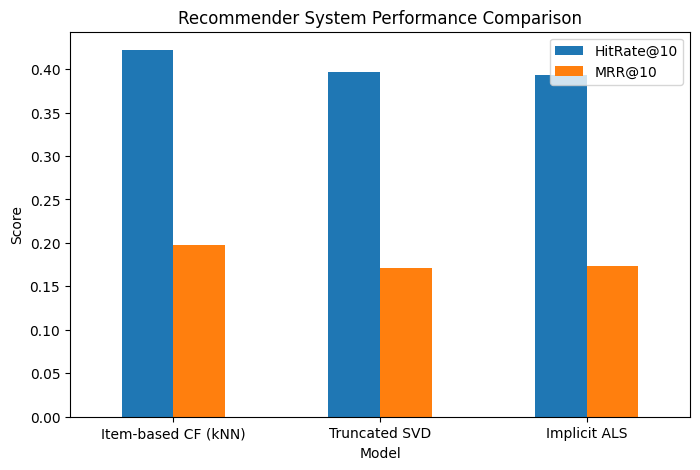

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["HitRate@10","MRR@10"]].plot.bar(figsize=(8,5))
plt.title("Recommender System Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Obtaining Substitutes using SVD**

In [ ]:
from sklearn.preprocessing import normalize

item_names = np.array(item_index)          # length n_items
item_to_col = {name: j for j, name in enumerate(item_names)}

# item embedding matrix: (n_items × k)
E = Vt.T.astype(np.float32)

# L2 normalize rows (so dot product = cosine similarity)
E = normalize(E, norm="l2", axis=1)

In [ ]:
import scipy.sparse as sp

# X_ui should be BINARY users×items (or orders×items). Orders is better if available.
# If your X_ui is per-user, this is "co-user" rather than "co-basket".
# Ideally build X_oi (orders×items). If not, use X_ui but interpret carefully.

X = X_ui.copy().astype(np.int8)
X.data[:] = 1  # force binary

# Co-occurrence counts: (items×items)
C = (X.T @ X).tocsr()
C.setdiag(0)
C.eliminate_zeros()

# Item frequencies
freq = np.array(X.sum(axis=0)).ravel().astype(np.float32)

In [ ]:
# products must have unique product_name rows
meta = (products
        .drop_duplicates(subset=["product_name"])
        .set_index("product_name")
        .reindex(item_names))

# optional columns: 'brand', 'category', 'price'

In [ ]:
def substitute_candidates_svd(product_name: str,
                              topn: int = 10,
                              pool: int = 200,
                              same_category: bool = True,
                              different_brand: bool = True,
                              price_pct: float = 0.30,
                              w_sim: float = 1.0,
                              w_copurchase: float = 1.0,
                              w_price: float = 0.3):
    """
    Automatic substitutes using SVD embeddings.
    - pool: how many nearest neighbors to consider before filtering/reranking
    - w_sim: weight on embedding similarity
    - w_copurchase: penalty weight for co-purchase (to avoid complements)
    - w_price: weight for price similarity (optional; set to 0 to disable)
    """

    if product_name not in item_to_col:
        return pd.DataFrame(columns=["candidate", "sub_score", "cos_sim", "jaccard", "price_sim", "brand", "category", "price"])

    i = item_to_col[product_name]
    v = E[i]  # normalized embedding

    # cosine similarities to all items
    sims = E @ v  # (n_items,)
    sims[i] = -np.inf

    # take a candidate pool of most similar items
    cand_idx = np.argpartition(-sims, pool)[:pool]
    cand_idx = cand_idx[np.argsort(-sims[cand_idx])]

    # metadata of target
    target_cat = meta.loc[product_name, "category_sub"] if "category_sub" in meta.columns else None
    target_brand = meta.loc[product_name, "brand"] if "brand" in meta.columns else None
    target_price = meta.loc[product_name, "price_original"] if "price_original" in meta.columns else None

    rows = []
    for j in cand_idx:
        cand_name = item_names[j]

        # category/brand filters
        cand_cat = meta.loc[cand_name, "category_sub"] if "category_sub" in meta.columns else None
        cand_brand = meta.loc[cand_name, "brand"] if "brand" in meta.columns else None
        cand_price = meta.loc[cand_name, "price_original"] if "price_original" in meta.columns else None

        if same_category and (pd.notna(target_cat) and pd.notna(cand_cat)) and (cand_cat != target_cat):
            continue
        if different_brand and (pd.notna(target_brand) and pd.notna(cand_brand)) and (cand_brand == target_brand):
            continue

        # price similarity (optional)
        price_sim = np.nan
        if w_price > 0 and pd.notna(target_price) and pd.notna(cand_price) and target_price > 0:
            rel_diff = abs(cand_price - target_price) / target_price
            if rel_diff > price_pct:
                continue
            price_sim = 1.0 - rel_diff  # 1 is perfect, 0.7 means 30% diff, etc.
        else:
            w_price = 0.0  # effectively disable if missing

        # co-purchase penalty via Jaccard
        co = C[i, j] if C.shape[0] > max(i, j) else 0
        if hasattr(co, "A"):
            co = float(co.A[0][0])
        else:
            co = float(co)

        denom = freq[i] + freq[j] - co
        jacc = (co / denom) if denom > 0 else 0.0  # higher => more complements

        cos_sim = float(sims[j])

        # Substitute score: high similarity, low jaccard
        sub_score = (w_sim * cos_sim) - (w_copurchase * jacc) + (w_price * (price_sim if pd.notna(price_sim) else 0.0))

        rows.append([cand_name, sub_score, cos_sim, jacc, price_sim, cand_brand, cand_cat, cand_price])

        if len(rows) >= topn:
            # we don't break immediately because later rows could score higher after penalties,
            # but for speed we'll collect a bit more then sort.
            pass

    out = pd.DataFrame(rows, columns=["candidate", "sub_score", "cos_sim", "jaccard", "price_sim", "brand", "category", "price"])
    out = out.sort_values("sub_score", ascending=False).head(topn).reset_index(drop=True)
    return out

In [ ]:
substitute_candidates_svd("Lancome Hypnose Mascara 01", topn=10)

,candidate,sub_score,cos_sim,jaccard,price_sim,brand,category,price
0,Eyüp Sabri Tuncer Kolonyalı Mendil Çeşme Limon...,0.375306,0.375306,0.000000,NaN,NaN,NaN,NaN
1,Clinique Dramatically Different Lipstick 01 Ba...,0.301500,0.325890,0.024390,NaN,NaN,NaN,NaN
2,L'Oréal Paris Bambi Oversized Eye Mascara Black,0.301072,0.326072,0.025000,NaN,Loreal Paris Makyaj,Maskara,666.58
3,Shiseido Imperiallash Mascaraink 01 Mascara,0.279789,0.321456,0.041667,NaN,Shiseido,Maskara,2075.00
4,Estee Lauder Perfectionist Pro Rapid Lift Seru...,0.268704,0.268704,0.000000,NaN,NaN,NaN,NaN
5,Dior Diorskin Forever Glow Star Filter 2N,0.265392,0.314172,0.048780,NaN,NaN,NaN,NaN
6,Dior Diorskin Forever Glow Star Filter 5N,0.263786,0.313786,0.050000,NaN,NaN,NaN,NaN
7,Dior Diorskin Forever Glow Star Filter 3N,0.263786,0.313786,0.050000,NaN,NaN,NaN,NaN
8,L'Oréal Paris Telescopic Lift Suya Dayanıklı M...,0.236293,0.258515,0.022222,NaN,Loreal Paris Makyaj,Maskara,1499.92
9,Clinique Even Better Pop Ruj 07,0.224762,0.248572,0.023810,NaN,NaN,NaN,NaN


In [ ]:
substitute_candidates_svd(
    "Equal for Men Erkek Deodorant 150 Ml",
    same_category=True,
    different_brand=False,
    w_price=10.0
)

,candidate,sub_score,cos_sim,jaccard,price_sim,brand,category,price
0,Jagler Men Extreme Deo 150 Ml,10.780160,0.851588,0.071429,1.0,Jagler,Deodorant,66.67
1,Jagler Storm for Men Erkek Deodorant 150 Ml,10.768655,0.831155,0.062500,1.0,Jagler,Deodorant,66.67
2,Caldion Night for Men Erkek Deodorant 150 Ml,10.763034,0.825534,0.062500,1.0,Caldion,Deodorant,66.67
3,Jagler Blue Erkek Deodorant 150 Ml,10.753718,0.753718,0.000000,1.0,Jagler,Deodorant,66.67
4,Jagler Hero Men Deo 150 Ml,10.750291,0.850291,0.100000,1.0,Jagler,Deodorant,66.67
5,Jagler Sport for Men Erkek Deodorant 150 Ml,10.731595,0.808518,0.076923,1.0,Jagler,Deodorant,66.67
6,Jagler Energy Men Deo 150 Ml,10.716702,0.793625,0.076923,1.0,Jagler,Deodorant,66.67
7,Jagler for Men Erkek Deodorant 150 Ml,10.614815,0.658293,0.043478,1.0,Jagler,Deodorant,66.67
8,Caldion for Men Erkek Deodorant 150 Ml,10.605479,0.716590,0.111111,1.0,Caldion,Deodorant,66.67
9,Jagler Black for Men Erkek Deodorant 150 Ml,10.445303,0.516731,0.071429,1.0,Jagler,Deodorant,66.67


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


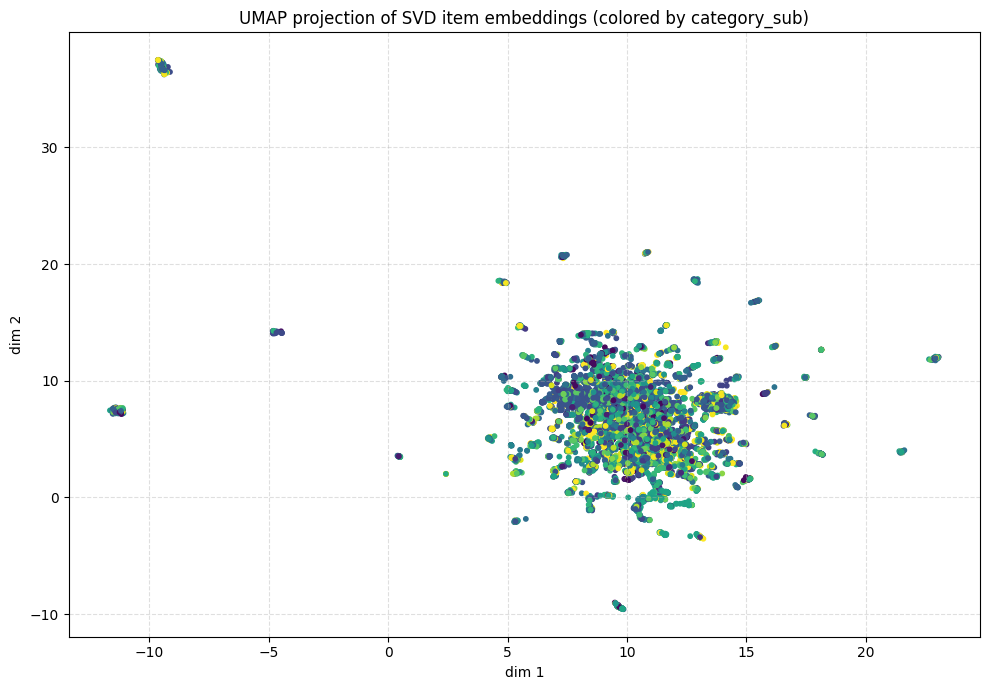

In [ ]:
# =========================
# Visualize SVD Item Embeddings with UMAP (preferred) or t-SNE (fallback)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize

# ---- Prereqs you already have from SVD workflow ----
# Vt: (k × n_items) from TruncatedSVD
# item_index: pandas Index or array-like of product names, length n_items
# products: DataFrame with columns: product_name, brand, category_sub, price_original

# -------------------------
# 1) Build normalized item embedding matrix E (n_items × k)
# -------------------------
item_names = np.array(item_index)                # length n_items
item_to_col = {name: j for j, name in enumerate(item_names)}

E = Vt.T.astype(np.float32)                      # (n_items × k)
E = normalize(E, norm="l2", axis=1)              # cosine-friendly

# -------------------------
# 2) Build metadata aligned to item_names
# -------------------------
meta = (products[["product_name", "brand", "category_sub", "price_original"]]
        .drop_duplicates(subset=["product_name"])
        .set_index("product_name")
        .reindex(item_names))

# -------------------------
# 3) Choose items to plot (optional sampling for speed)
#    - Plot all items by default (n_items ~ 11k is fine)
#    - If you want faster or less clutter: sample_size = 4000
# -------------------------
sample_size = None  # set to e.g. 4000 to sample
rng = np.random.default_rng(42)

if sample_size is None or sample_size >= E.shape[0]:
    plot_idx = np.arange(E.shape[0], dtype=np.int32)
else:
    plot_idx = rng.choice(E.shape[0], size=sample_size, replace=False).astype(np.int32)

E_plot = E[plot_idx]
names_plot = item_names[plot_idx]
meta_plot = meta.iloc[plot_idx].reset_index(drop=True)

# -------------------------
# 4) Dimensionality reduction: UMAP (preferred), else t-SNE
# -------------------------
use_umap = True  # set False to force t-SNE

XY = None
method_used = None

if use_umap:
    try:
        import umap
        reducer = umap.UMAP(
            n_neighbors=30,
            min_dist=0.15,
            n_components=2,
            metric="cosine",
            random_state=42
        )
        XY = reducer.fit_transform(E_plot)
        method_used = "UMAP"
    except Exception as e:
        print("UMAP not available or failed:", repr(e))
        print("Falling back to t-SNE. (Tip: pip install umap-learn)")
        use_umap = False

if not use_umap:
    from sklearn.manifold import TSNE
    reducer = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    XY = reducer.fit_transform(E_plot)
    method_used = "t-SNE"

# -------------------------
# 5) Plot: cluster view colored by category_sub (optional)
#    IMPORTANT: No seaborn, no manual color setting.
# -------------------------
# Map categories to integer codes for matplotlib coloring
cat_series = meta_plot["category_sub"].astype("string")
cat_codes = pd.Categorical(cat_series).codes  # -1 for missing
# Replace -1 (missing) with a separate code at the end
missing_mask = (cat_codes == -1)
if missing_mask.any():
    cat_codes = cat_codes.copy()
    cat_codes[missing_mask] = cat_codes.max() + 1

plt.figure(figsize=(10, 7))
plt.scatter(XY[:, 0], XY[:, 1], s=10, c=cat_codes)
plt.title(f"{method_used} projection of SVD item embeddings (colored by category_sub)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# -------------------------
# 6) (Optional) Highlight one product + its top substitutes
#    - Requires your substitute function OR a simple cosine neighbor finder.
# -------------------------

def top_cosine_neighbors(product_name, topn=10, pool=None):
    """Top neighbors by cosine similarity in SVD space. (No co-purchase penalty here.)"""
    if product_name not in item_to_col:
        return []
    i = item_to_col[product_name]
    v = E[i]
    sims = E @ v
    sims[i] = -np.inf
    if pool is None:
        idx = np.argpartition(-sims, topn)[:topn]
        idx = idx[np.argsort(-sims[idx])]
    else:
        idx = np.argpartition(-sims, pool)[:pool]
        idx = idx[np.argsort(-sims[idx])][:topn]
    return item_names[idx].tolist()

# Choose a product to highlight (change to something you care about)
query_product = None  # e.g. "Elidor Onarici Sampuani 400 Ml"

# If you want to highlight, set query_product to a valid product name:
if query_product is not None and query_product in item_to_col:
    subs = top_cosine_neighbors(query_product, topn=10)

    # Ensure query and subs are included in plot sample; if not, add them
    highlight_names = [query_product] + subs
    highlight_cols = [item_to_col[n] for n in highlight_names if n in item_to_col]

    # Compute XY for highlight points:
    # If we sampled, some highlighted items may not be in plot_idx; handle by projecting them separately
    # using the same reducer (UMAP supports transform; t-SNE does not).
    # We'll do a pragmatic approach: if UMAP, transform; else resample includes them.

    if method_used == "UMAP":
        # Rebuild reducer on E_plot already fit; transform highlight vectors
        highlight_vecs = E[np.array(highlight_cols, dtype=np.int32)]
        XY_h = reducer.transform(highlight_vecs)
        labels_h = [item_names[c] for c in highlight_cols]
    else:
        print("t-SNE does not support transform() reliably. For highlighting, set use_umap=True.")
        XY_h = None

    if XY_h is not None:
        plt.figure(figsize=(10, 7))
        # background
        plt.scatter(XY[:, 0], XY[:, 1], s=10, c=cat_codes, alpha=0.35)
        # highlights (no manual colors; just different marker/size)
        plt.scatter(XY_h[:, 0], XY_h[:, 1], s=80, marker="x")

        # label only the query + a few substitutes to avoid clutter
        for (x, y, label) in zip(XY_h[:, 0], XY_h[:, 1], labels_h):
            plt.text(x, y, label, fontsize=8)

        plt.title(f"{method_used} embedding view — query item + nearest neighbors")
        plt.xlabel("dim 1")
        plt.ylabel("dim 2")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()